In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
print("Libraries imported! ✅")

Libraries imported! ✅


In [2]:
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
print("Downloading data... please wait!")
df = pd.read_csv(url)
print(f"Data loaded successfully! ✅")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nColumns:")
print(df.columns.tolist())

Data loaded successfully! ✅
Total rows: 429,435
Total columns: 67

Columns:
['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'pe

In [3]:
df = df[['location', 'date', 'total_cases', 'new_cases', 
         'total_deaths', 'new_deaths', 'total_vaccinations',
         'people_vaccinated', 'continent']]
df['date'] = pd.to_datetime(df['date'])
print("Missing values:")
print(df.isnull().sum())
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"\nTotal countries: {df['location'].nunique()}")

Missing values:
location                   0
date                       0
total_cases            17631
new_cases              19276
total_deaths           17631
new_deaths             18827
total_vaccinations    344018
people_vaccinated     348303
continent              26525
dtype: int64

Date range: 2020-01-01 00:00:00 to 2024-08-14 00:00:00

Total countries: 255


C:\Users\DELL\AppData\Local\Temp\ipykernel_3508\181113036.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_cases', y='location', data=latest, palette='Reds_r')


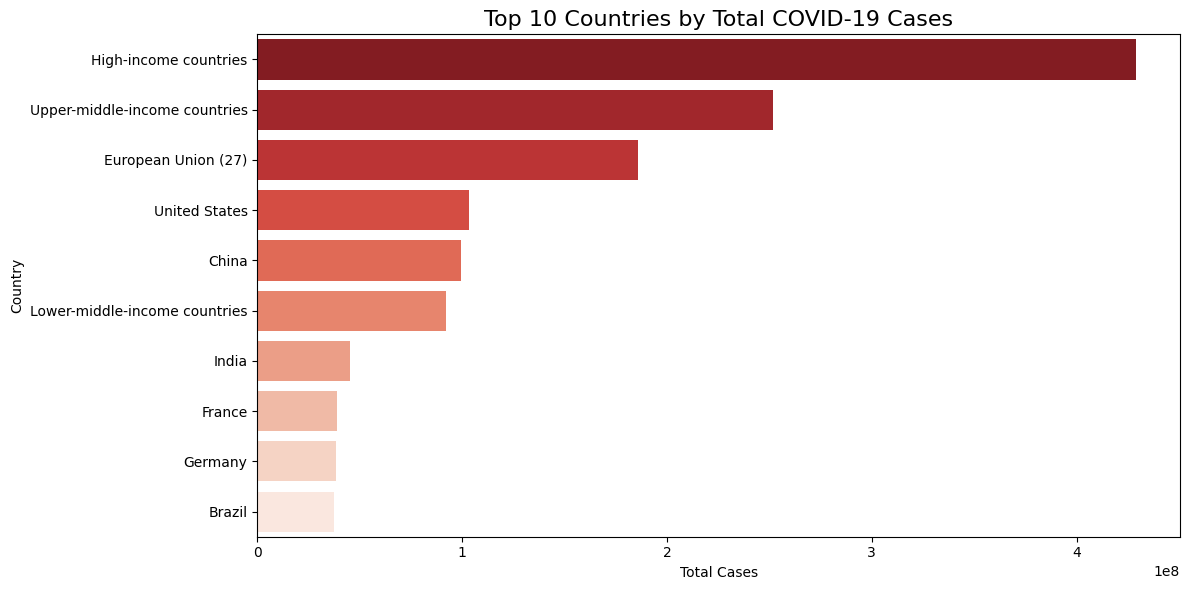

In [4]:
latest = df.groupby('location')['total_cases'].max().reset_index()
latest = latest.sort_values('total_cases', ascending=False)
exclude = ['World', 'Asia', 'Europe', 'North America', 
           'South America', 'Africa', 'Oceania', 
           'High income', 'Low income', 'European Union']
latest = latest[~latest['location'].isin(exclude)].head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='total_cases', y='location', data=latest, palette='Reds_r')
plt.title('Top 10 Countries by Total COVID-19 Cases', fontsize=16)
plt.xlabel('Total Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_countries.png', dpi=150)
plt.show()

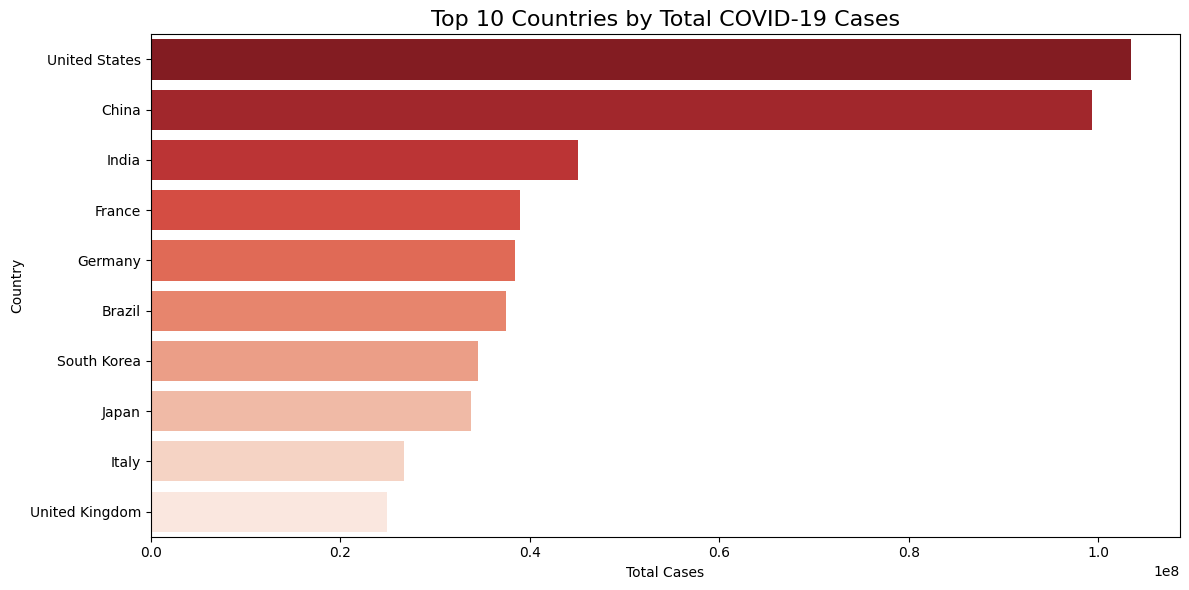

In [5]:
latest = df.groupby('location')['total_cases'].max().reset_index()
latest = latest.sort_values('total_cases', ascending=False)
exclude = ['World', 'Asia', 'Europe', 'North America', 
           'South America', 'Africa', 'Oceania',
           'High income', 'Low income', 'High-income countries',
           'Upper-middle-income countries', 'Lower-middle-income countries',
           'European Union', 'European Union (27)',
           'Middle income', 'Lower middle income', 'Upper middle income',
           'International']
latest = latest[~latest['location'].isin(exclude)].head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='total_cases', y='location', 
            data=latest, hue='location', palette='Reds_r', legend=False)
plt.title('Top 10 Countries by Total COVID-19 Cases', fontsize=16)
plt.xlabel('Total Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_countries.png', dpi=150)
plt.show()

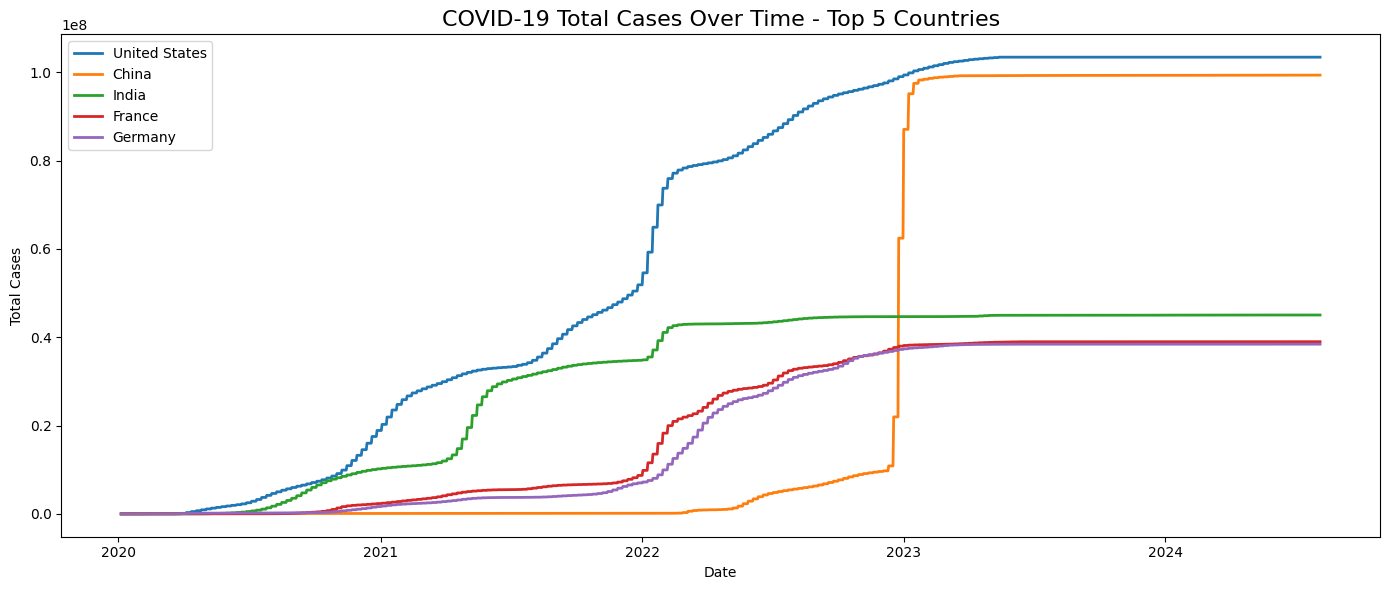

In [6]:
top5 = ['United States', 'China', 'India', 'France', 'Germany']
df_top5 = df[df['location'].isin(top5)]
plt.figure(figsize=(14, 6))
for country in top5:
    data = df_top5[df_top5['location'] == country]
    plt.plot(data['date'], data['total_cases'], label=country, linewidth=2)
plt.title('COVID-19 Total Cases Over Time - Top 5 Countries', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.tight_layout()
plt.savefig('cases_over_time.png', dpi=150)
plt.show()

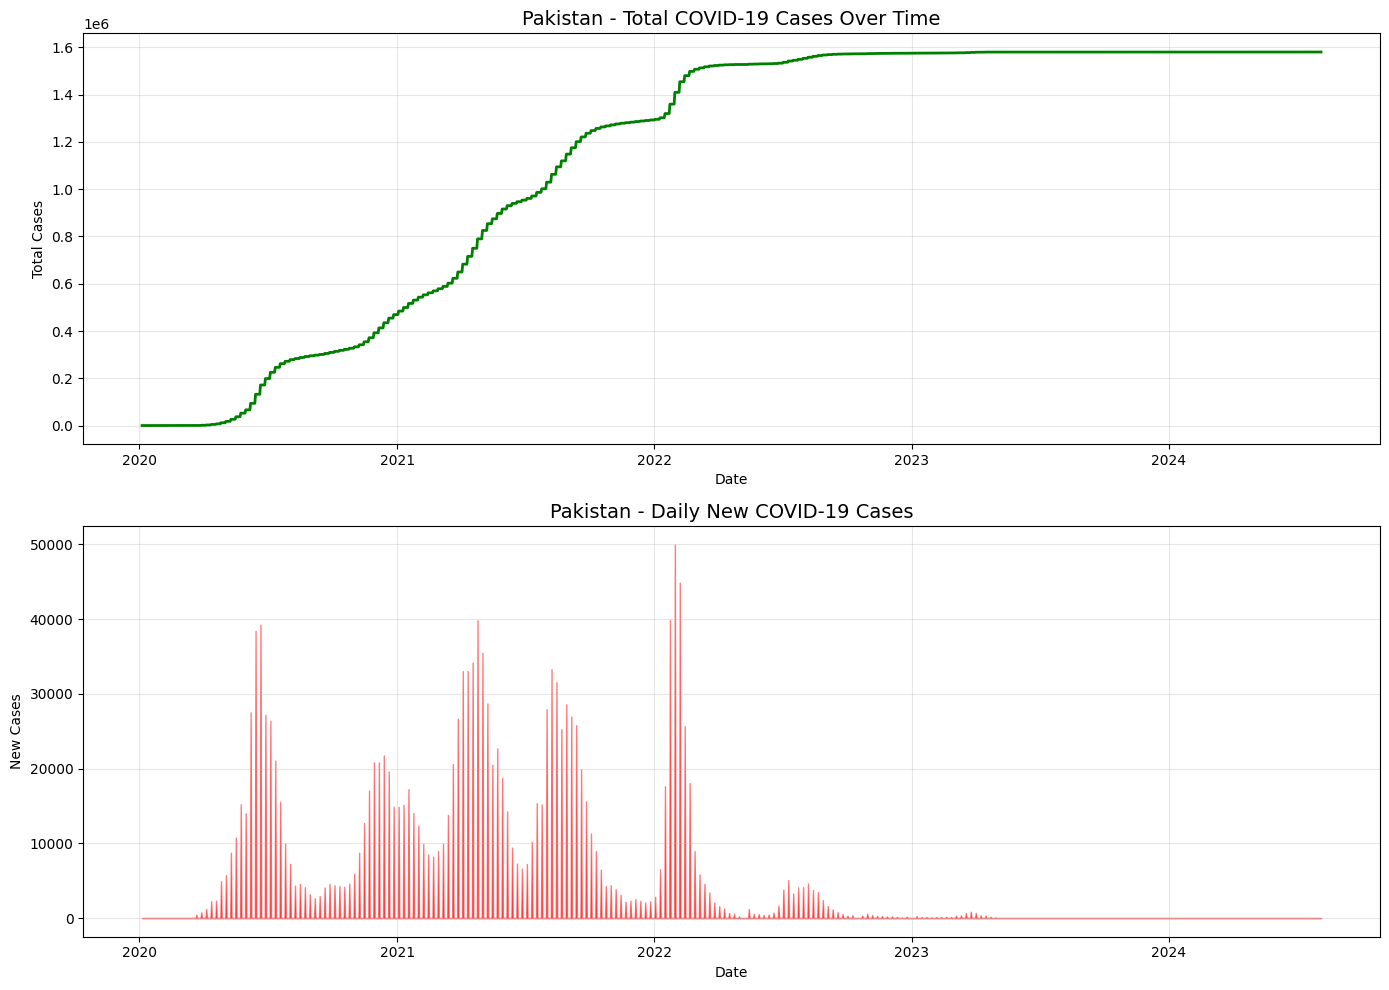

In [7]:
pakistan = df[df['location'] == 'Pakistan'].copy()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
ax1.plot(pakistan['date'], pakistan['total_cases'], 
         color='green', linewidth=2)
ax1.set_title('Pakistan - Total COVID-19 Cases Over Time', fontsize=14)
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Cases')
ax1.grid(True, alpha=0.3)
ax2.fill_between(pakistan['date'], pakistan['new_cases'], 
                 color='red', alpha=0.5)
ax2.set_title('Pakistan - Daily New COVID-19 Cases', fontsize=14)
ax2.set_xlabel('Date')
ax2.set_ylabel('New Cases')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pakistan_covid.png', dpi=150)
plt.show()

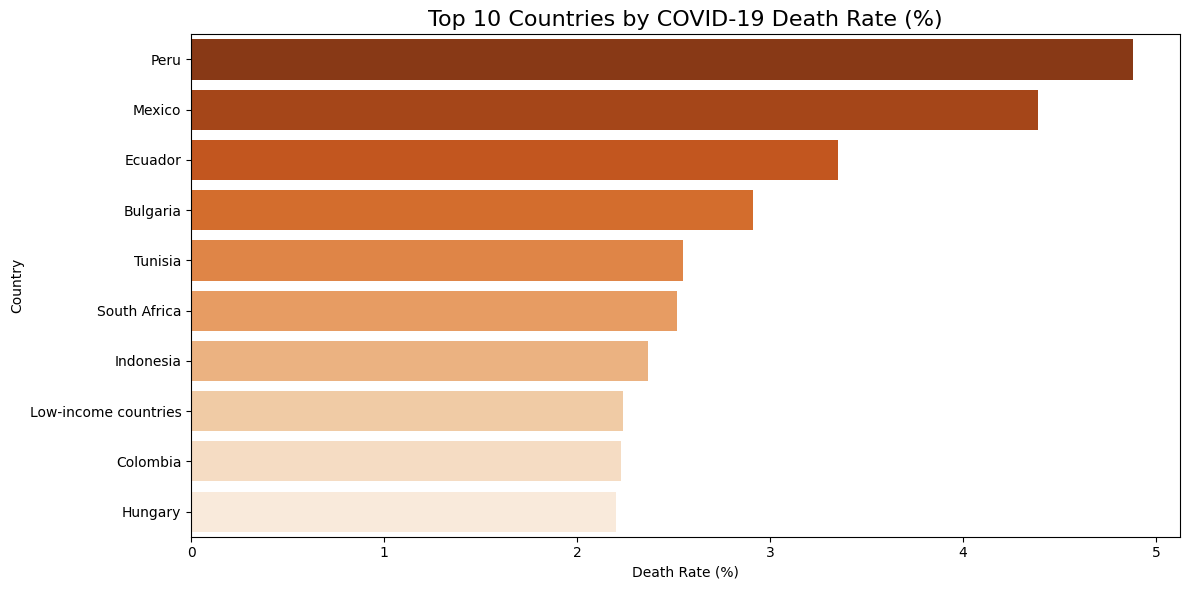

In [8]:
latest2 = df.groupby('location').agg(
    total_cases=('total_cases', 'max'),
    total_deaths=('total_deaths', 'max')
).reset_index()
latest2['death_rate'] = (latest2['total_deaths'] / 
                          latest2['total_cases'] * 100).round(2)
exclude = ['World', 'Asia', 'Europe', 'North America',
           'South America', 'Africa', 'Oceania',
           'High income', 'Low income', 'High-income countries',
           'Upper-middle-income countries', 'Lower-middle-income countries',
           'European Union', 'European Union (27)',
           'Middle income', 'International']
latest2 = latest2[~latest2['location'].isin(exclude)]
latest2 = latest2[latest2['total_cases'] > 1000000]
latest2 = latest2.sort_values('death_rate', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='death_rate', y='location',
            data=latest2, hue='location', palette='Oranges_r', legend=False)
plt.title('Top 10 Countries by COVID-19 Death Rate (%)', fontsize=16)
plt.xlabel('Death Rate (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('death_rate.png', dpi=150)
plt.show()